# 09C — Three-Role MVP Scope Freeze Audit

## 这一步做什么

09B发现，角色模型对以下三种角色代表在2024年大选后的表现达到最低要求：

- Labour：当前评测时期的执政党代表；
- Conservative：当前评测时期的主要反对党代表；
- Liberal Democrat：当前评测时期的较小反对党代表。

Green在大选后没有达到预先设定的最差政党门槛，因此本MVP不再声称覆盖所有四个政党，而是把产品目标缩小为“预测三种议会角色代表”。

这里不会永久把某个政党写死为某种角色。该映射只在`2024-07-05`之后、下一次大选或政府更替之前有效；未来政治角色变化时，系统必须先更新时间映射，再进行预测。

09C不会重新训练模型，也不会删除历史文件。它只会：

1. 读取09B已经保存的预测；
2. 验证大选后三个政党与三种角色的映射；
3. 在三党MVP范围内重新计算既有指标；
4. 把Green记录为范围外和产品局限；
5. 冻结产品范围、模型、阈值、融合比例和验收结果；
6. 生成SHA-256，防止最终Test之前继续修改规则。

**本Notebook不训练模型、不读取Test、不调用API。**


## 为什么最低Macro-F1门槛设为0.50

`0.50`是产品验收规则，不是数学定律，也不是从09B结果中反推出来的。

二分类Macro-F1分别计算“支持”和“反对”的F1，再取平均。如果模型永远预测多数类别，它在多数类别上可能看起来准确，但少数类别F1会是0，最终Macro-F1通常只有约0.33–0.41。

因此这里将0.50解释为：

> 模型至少开始对支持和反对两类都具有基本识别能力，不能只依赖多数类别。

它只是最低可用线，不表示0.50已经是优秀模型。更高要求仍由整体、大选后表现和与简单基准的差值共同控制。


## 为什么范围可以缩小，但不能隐藏Green

产品经理可以为MVP选择明确目标用户和功能边界。三角色MVP是一个可以解释的范围：每种议会制度角色选择一个代表。

但是必须透明记录：

- 四党模型没有通过最差政党门槛；
- Green不是因为缺少数据而被清理掉；
- Green仍保留在原始数据、09和09B审计结果中；
- 最终产品结论不能推广到Green或所有英国政党。

这叫产品范围缩减，不叫数据清洗。


In [1]:
# 导入免费范围审计需要的库；这里不导入训练器或API客户端
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd()
MODEL_DIR = BASE_DIR / "processed" / "model_v2"
INPUT_DIR = BASE_DIR / "processed" / "role_invariant_challenge_v2"
OUTPUT_DIR = BASE_DIR / "processed" / "three_role_scope_freeze_v1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = MODEL_DIR / "model_train_v2.csv"
VALIDATION_PATH = MODEL_DIR / "model_validation_v2.csv"
PREDICTIONS_PATH = INPUT_DIR / "role_model_comparison_predictions_v2.csv"
PARENT_RECOMMENDATION_PATH = INPUT_DIR / "role_model_recommendation_v2.json"

TARGET = "target_binary_support"
ELECTION_DATE = pd.Timestamp("2024-07-05")
ROLE_MAPPING_EFFECTIVE_FROM = "2024-07-05"
ROLE_MAPPING_EFFECTIVE_UNTIL = "next UK general election or government change"
CLASSIFICATION_THRESHOLD = 0.50

# MVP政党范围在最终Test之前固定；制度角色映射具有明确生效期
IN_SCOPE_PARTIES = [
    "labour",
    "conservative",
    "liberal-democrat",
]
OUT_OF_SCOPE_PARTIES = ["green"]
EXPECTED_POST_ELECTION_ROLES = {
    "labour": "governing_party",
    "conservative": "main_opposition",
    "liberal-democrat": "smaller_opposition",
}

PRIMARY_MODEL = "role_prior_blend_50_50"
BASELINE_MODEL = "rolling_100_party_prior"
ROLE_MODEL_WEIGHT = 0.50
RECENT_PRIOR_WEIGHT = 0.50

# 沿用09B预先设定的门槛，不根据09C结果调整
MIN_POST_IMPROVEMENT = 0.03
MIN_MEAN_FOLD_MACRO_F1 = 0.60
MIN_WORST_FOLD_MACRO_F1 = 0.50
MIN_POST_WORST_PARTY_MACRO_F1 = 0.50

print("Notebook version: 09c-three-role-scope-freeze-v1")
print("Model training: 0")
print("API calls: 0")
print("LLM calls: 0")
print("Test loaded: False")
print("Output directory:", OUTPUT_DIR)


Notebook version: 09c-three-role-scope-freeze-v1
Model training: 0
API calls: 0
LLM calls: 0
Test loaded: False
Output directory: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/three_role_scope_freeze_v1


## 1. 读取09B既有预测和开发数据

09C不得产生新的预测。它只对09B已经保存的同一批预测重新划定产品范围并计算指标。

Train和Validation只用于验证角色映射；不会拟合任何模型。


In [2]:
# 读取09B已经生成的预测以及角色审计所需字段
predictions = pd.read_csv(PREDICTIONS_PATH)
train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VALIDATION_PATH)
parent_recommendation = json.loads(
    PARENT_RECOMMENDATION_PATH.read_text(encoding="utf-8")
)

for frame in (train, validation):
    frame["motion_date"] = pd.to_datetime(frame["motion_date"])
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)

predictions["motion_date"] = pd.to_datetime(predictions["motion_date"])
predictions[TARGET] = pd.to_numeric(
    predictions[TARGET], errors="raise"
).astype(int)
predictions["probability"] = pd.to_numeric(
    predictions["probability"], errors="raise"
)

required_prediction_columns = {
    "row_id",
    "division_key",
    "motion_date",
    "party",
    "fold",
    "era",
    "model",
    "probability",
    "prediction",
    TARGET,
}
missing_columns = required_prediction_columns - set(predictions.columns)
assert not missing_columns, f"09B预测缺少字段：{sorted(missing_columns)}"

available_models = set(predictions["model"].unique())
assert {PRIMARY_MODEL, BASELINE_MODEL}.issubset(available_models)
assert parent_recommendation["test_loaded"] is False
assert parent_recommendation["api_calls"] == 0

# 同一division不能跨Train和Validation
assert not set(train["division_key"]) & set(validation["division_key"])

development_roles = pd.concat([
    train[["row_id", "motion_date", "party", "party_role"]],
    validation[["row_id", "motion_date", "party", "party_role"]],
], ignore_index=True)

print("Prediction rows:", len(predictions))
print("Prediction models:", sorted(available_models))
print("Development role rows:", len(development_roles))


Prediction rows: 10170
Prediction models: ['expanding_party_prior', 'role_only_xgboost', 'role_prior_blend_50_50', 'rolling_100_party_prior', 'time_decay_xgboost']
Development role rows: 3392


## 2. 验证大选后的三种角色映射

产品范围不是简单选择三个分数较高的政党，而是要求三个政党在2024年大选后分别代表三种不同制度角色。

角色由日期和当时政治状态决定，不是永久属性。当前映射的有效期从`2024-07-05`开始，到下一次大选或政府更替为止。

如果角色映射与预期不一致，Notebook会停止，不能继续冻结范围。


In [3]:
# 只审计大选后记录，确认每个范围内政党的制度角色唯一且正确
post_roles = development_roles[
    (development_roles["motion_date"] >= ELECTION_DATE)
    & (development_roles["party"].isin(IN_SCOPE_PARTIES))
].copy()

role_audit = (
    post_roles.groupby("party")["party_role"]
    .agg(
        rows="size",
        unique_roles="nunique",
        observed_roles=lambda values: " | ".join(
            sorted(values.dropna().astype(str).unique())
        ),
    )
    .reset_index()
)
role_audit["expected_role"] = role_audit["party"].map(
    EXPECTED_POST_ELECTION_ROLES
)
role_audit["role_matches"] = (
    role_audit["unique_roles"].eq(1)
    & role_audit["observed_roles"].eq(role_audit["expected_role"])
)

if set(role_audit["party"]) != set(IN_SCOPE_PARTIES):
    raise ValueError("大选后数据未覆盖全部三个范围内政党。")
if not role_audit["role_matches"].all():
    raise ValueError("三党与制度角色映射不符合冻结定义。")

role_audit.to_csv(
    OUTPUT_DIR / "three_role_mapping_audit_v1.csv", index=False
)
display(role_audit)


,party,rows,unique_roles,observed_roles,expected_role,role_matches
0,conservative,54,1,main_opposition,main_opposition,True
1,labour,63,1,governing_party,governing_party,True
2,liberal-democrat,41,1,smaller_opposition,smaller_opposition,True


## 3. 建立三角色MVP评测范围

这里只过滤评价对象，不修改09B概率：

- 三个范围内政党的每一条概率必须与09B完全一致；
- Green预测仍保存在09B原始产物中；
- 09C输出额外保存范围外审计摘要。


In [4]:
# 把三个角色代表与范围外Green分开保存，保留完整审计链
scope_predictions = predictions[
    predictions["party"].isin(IN_SCOPE_PARTIES)
].copy()
out_of_scope_predictions = predictions[
    predictions["party"].isin(OUT_OF_SCOPE_PARTIES)
].copy()

assert len(scope_predictions) + len(out_of_scope_predictions) == len(predictions)
assert set(scope_predictions["party"].unique()) == set(IN_SCOPE_PARTIES)
assert set(out_of_scope_predictions["party"].unique()) == set(
    OUT_OF_SCOPE_PARTIES
)

# 每个模型必须覆盖相同的三党评测行
scope_coverage = scope_predictions.groupby("model").agg(
    rows=("row_id", "size"),
    unique_rows=("row_id", "nunique"),
    divisions=("division_key", "nunique"),
    folds=("fold", "nunique"),
    parties=("party", "nunique"),
)
assert scope_coverage["rows"].nunique() == 1
assert scope_coverage["unique_rows"].nunique() == 1
assert (scope_coverage["folds"] == 6).all()
assert (scope_coverage["parties"] == 3).all()

scope_predictions.to_csv(
    OUTPUT_DIR / "three_role_existing_predictions_v1.csv", index=False
)

out_of_scope_summary = out_of_scope_predictions.groupby(
    ["model", "party"], as_index=False
).agg(
    rows=("row_id", "size"),
    divisions=("division_key", "nunique"),
    first_date=("motion_date", "min"),
    last_date=("motion_date", "max"),
)
out_of_scope_summary["scope_status"] = "out_of_scope_retained_for_audit"
out_of_scope_summary["reason"] = (
    "MVP targets one representative for each of three parliamentary roles; "
    "four-party validation did not satisfy the predeclared worst-party gate."
)
out_of_scope_summary.to_csv(
    OUTPUT_DIR / "out_of_scope_party_audit_v1.csv", index=False
)

display(scope_coverage)
display(out_of_scope_summary)


,rows,unique_rows,divisions,folds,parties
model,,,,,
expanding_party_prior,1554,1554,572,6,3
role_only_xgboost,1554,1554,572,6,3
role_prior_blend_50_50,1554,1554,572,6,3
rolling_100_party_prior,1554,1554,572,6,3
time_decay_xgboost,1554,1554,572,6,3


,model,party,rows,divisions,first_date,last_date,scope_status,reason
0,expanding_party_prior,green,480,480,2021-01-06,2024-12-17,out_of_scope_retained_for_audit,MVP targets one representative for each of thr...
1,role_only_xgboost,green,480,480,2021-01-06,2024-12-17,out_of_scope_retained_for_audit,MVP targets one representative for each of thr...
2,role_prior_blend_50_50,green,480,480,2021-01-06,2024-12-17,out_of_scope_retained_for_audit,MVP targets one representative for each of thr...
3,rolling_100_party_prior,green,480,480,2021-01-06,2024-12-17,out_of_scope_retained_for_audit,MVP targets one representative for each of thr...
4,time_decay_xgboost,green,480,480,2021-01-06,2024-12-17,out_of_scope_retained_for_audit,MVP targets one representative for each of thr...


## 4. 重新计算三党范围内的指标

仍使用固定0.50分类阈值。

评价包括：

- 六个fold平均Macro-F1；
- 最差fold Macro-F1；
- 大选后整体Macro-F1；
- 大选后最差政党Macro-F1；
- 大选后每个制度角色的Macro-F1；
- 概率Brier误差。


In [5]:
def safe_roc_auc(y_true, probabilities):
    # 单一类别分组无法定义ROC-AUC
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, probabilities)


def evaluate_probabilities(y_true, probabilities):
    # 固定0.50阈值，同时评价分类和概率质量
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predicted = (probabilities >= CLASSIFICATION_THRESHOLD).astype(int)
    return {
        "rows": len(y_true),
        "accuracy": accuracy_score(y_true, predicted),
        "balanced_accuracy": balanced_accuracy_score(y_true, predicted),
        "macro_f1": f1_score(
            y_true, predicted, average="macro", zero_division=0
        ),
        "support_precision": precision_score(
            y_true, predicted, zero_division=0
        ),
        "support_recall": recall_score(
            y_true, predicted, zero_division=0
        ),
        "roc_auc": safe_roc_auc(y_true, probabilities),
        "brier": brier_score_loss(y_true, probabilities),
    }


def grouped_metrics(frame, group_columns):
    # 对模型、fold、政党或角色分组使用相同指标
    rows = []
    for keys, group in frame.groupby(group_columns, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        record = dict(zip(group_columns, keys))
        record.update(evaluate_probabilities(
            group[TARGET], group["probability"]
        ))
        rows.append(record)
    return pd.DataFrame(rows)


aggregate_metrics = grouped_metrics(scope_predictions, ["model"])
fold_metrics = grouped_metrics(
    scope_predictions, ["model", "fold", "era"]
)
party_metrics = grouped_metrics(
    scope_predictions, ["model", "party"]
)

post_scope = scope_predictions[
    scope_predictions["era"] == "post_election"
].copy()
post_metrics = grouped_metrics(post_scope, ["model"])
post_party_metrics = grouped_metrics(post_scope, ["model", "party"])

# 把大选后政党映射为产品角色，生成角色级审计
post_role_predictions = post_scope.copy()
post_role_predictions["product_role"] = post_role_predictions["party"].map(
    EXPECTED_POST_ELECTION_ROLES
)
post_role_metrics = grouped_metrics(
    post_role_predictions, ["model", "product_role"]
)

fold_summary = fold_metrics.groupby("model").agg(
    mean_fold_macro_f1=("macro_f1", "mean"),
    worst_fold_macro_f1=("macro_f1", "min"),
).reset_index()

post_summary = post_metrics.rename(columns={
    "macro_f1": "post_election_macro_f1",
    "accuracy": "post_election_accuracy",
    "roc_auc": "post_election_roc_auc",
    "brier": "post_election_brier",
})[[
    "model",
    "post_election_macro_f1",
    "post_election_accuracy",
    "post_election_roc_auc",
    "post_election_brier",
]]

post_worst_party = (
    post_party_metrics.groupby("model")["macro_f1"]
    .min()
    .reset_index(name="post_worst_party_macro_f1")
)

early_late = fold_metrics[
    fold_metrics["fold"].isin(["2024_early_post", "2024_late_post"])
][["model", "fold", "macro_f1"]].pivot(
    index="model", columns="fold", values="macro_f1"
).reset_index().rename(columns={
    "2024_early_post": "early_post_macro_f1",
    "2024_late_post": "late_post_macro_f1",
})

model_comparison = (
    aggregate_metrics
    .merge(fold_summary, on="model", how="left")
    .merge(post_summary, on="model", how="left")
    .merge(post_worst_party, on="model", how="left")
    .merge(early_late, on="model", how="left")
    .sort_values("post_election_macro_f1", ascending=False)
    .reset_index(drop=True)
)

model_comparison.to_csv(
    OUTPUT_DIR / "three_role_model_comparison_v1.csv", index=False
)
fold_metrics.to_csv(
    OUTPUT_DIR / "three_role_fold_metrics_v1.csv", index=False
)
party_metrics.to_csv(
    OUTPUT_DIR / "three_role_party_metrics_v1.csv", index=False
)
post_party_metrics.to_csv(
    OUTPUT_DIR / "three_role_post_party_metrics_v1.csv", index=False
)
post_role_metrics.to_csv(
    OUTPUT_DIR / "three_role_post_role_metrics_v1.csv", index=False
)

display(model_comparison.round(3))
display(
    post_party_metrics.pivot(
        index="model", columns="party", values="macro_f1"
    ).round(3)
)
display(
    post_role_metrics.pivot(
        index="model", columns="product_role", values="macro_f1"
    ).round(3)
)


,model,rows,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,roc_auc,brier,mean_fold_macro_f1,worst_fold_macro_f1,post_election_macro_f1,post_election_accuracy,post_election_roc_auc,post_election_brier,post_worst_party_macro_f1,early_post_macro_f1,late_post_macro_f1
0,role_prior_blend_50_50,1554,0.799,0.783,0.788,0.797,0.878,0.883,0.158,0.753,0.578,0.719,0.722,0.800,0.195,0.534,0.578,0.784
1,role_only_xgboost,1554,0.790,0.780,0.782,0.807,0.840,0.894,0.133,0.744,0.627,0.690,0.690,0.770,0.195,0.539,0.627,0.719
2,time_decay_xgboost,1554,0.808,0.804,0.803,0.840,0.829,0.897,0.130,0.740,0.449,0.614,0.614,0.630,0.245,0.548,0.449,0.690
3,expanding_party_prior,1554,0.581,0.528,0.496,0.599,0.851,0.574,0.241,0.495,0.355,0.595,0.608,0.623,0.241,0.344,0.497,0.642
4,rolling_100_party_prior,1554,0.658,0.639,0.640,0.688,0.755,0.645,0.227,0.622,0.497,0.595,0.608,0.623,0.239,0.344,0.497,0.642


party,conservative,labour,liberal-democrat
model,,,
expanding_party_prior,0.386,0.344,0.414
role_only_xgboost,0.732,0.730,0.539
role_prior_blend_50_50,0.810,0.629,0.534
rolling_100_party_prior,0.386,0.344,0.414
time_decay_xgboost,0.570,0.679,0.548


product_role,governing_party,main_opposition,smaller_opposition
model,,,
expanding_party_prior,0.344,0.386,0.414
role_only_xgboost,0.730,0.732,0.539
role_prior_blend_50_50,0.629,0.810,0.534
rolling_100_party_prior,0.344,0.386,0.414
time_decay_xgboost,0.679,0.570,0.548


## 5. 沿用09B门槛决定是否冻结融合模型

09C不会发明新门槛。融合模型必须满足09B已经声明的四项要求：

1. 大选后Macro-F1至少比最近100票基准高0.03；
2. 六个fold平均Macro-F1至少0.60；
3. 最差fold Macro-F1至少0.50；
4. 大选后最差范围内政党Macro-F1至少0.50。

只有四项全部通过，才冻结为三角色MVP正式预测模型。


In [6]:
comparison_indexed = model_comparison.set_index("model")
primary = comparison_indexed.loc[PRIMARY_MODEL]
baseline = comparison_indexed.loc[BASELINE_MODEL]

acceptance_gates = {
    "post_election_improvement_gate": bool(
        primary["post_election_macro_f1"]
        >= baseline["post_election_macro_f1"] + MIN_POST_IMPROVEMENT
    ),
    "mean_fold_gate": bool(
        primary["mean_fold_macro_f1"] >= MIN_MEAN_FOLD_MACRO_F1
    ),
    "worst_fold_gate": bool(
        primary["worst_fold_macro_f1"] >= MIN_WORST_FOLD_MACRO_F1
    ),
    "post_worst_party_gate": bool(
        primary["post_worst_party_macro_f1"]
        >= MIN_POST_WORST_PARTY_MACRO_F1
    ),
}

scope_model_passes = all(acceptance_gates.values())
frozen_model = PRIMARY_MODEL if scope_model_passes else BASELINE_MODEL

if scope_model_passes:
    next_step = (
        "Freeze the three-role MVP and prepare the one-time final Test protocol."
    )
else:
    next_step = (
        "The three-role scope still fails; freeze Rolling-100 Party Prior "
        "and do not continue model tuning."
    )

print("Acceptance gates:", acceptance_gates)
print("Three-role model passes:", scope_model_passes)
print("Frozen model:", frozen_model)
print("Next step:", next_step)


Acceptance gates: {'post_election_improvement_gate': True, 'mean_fold_gate': True, 'worst_fold_gate': True, 'post_worst_party_gate': True}
Three-role model passes: True
Frozen model: role_prior_blend_50_50
Next step: Freeze the three-role MVP and prepare the one-time final Test protocol.


## 6. 冻结产品范围和模型配置

冻结清单会记录：

- 三个范围内政党和对应角色；
- Green范围外状态及原因；
- 正式模型和简单基准；
- 50/50融合比例；
- 0.50分类阈值；
- 验收门槛及结果；
- 未使用Test和API；
- 配置SHA-256。

最终Test必须读取这份清单，若内容发生改变就应停止运行。


In [7]:
# 所有值先转换成标准Python类型，避免NumPy布尔值无法写入JSON
freeze_payload = {
    "notebook_version": "09c-three-role-scope-freeze-v1",
    "created_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
    "product_name": "Three-role parliamentary stance MVP",
    "prediction_target": "policy-object support, not raw Aye/No",
    "in_scope_parties": IN_SCOPE_PARTIES,
    "out_of_scope_parties": OUT_OF_SCOPE_PARTIES,
    "post_election_role_mapping": EXPECTED_POST_ELECTION_ROLES,
    "role_mapping_effective_from": ROLE_MAPPING_EFFECTIVE_FROM,
    "role_mapping_effective_until": ROLE_MAPPING_EFFECTIVE_UNTIL,
    "role_mapping_policy": (
        "Assign roles from the prediction date and current parliamentary "
        "government; refresh after every election or government change."
    ),
    "out_of_scope_reason": (
        "MVP predicts one representative of each parliamentary role. "
        "The four-party development evaluation did not satisfy the "
        "predeclared worst-party Macro-F1 gate; Green remains in audit data."
    ),
    "scope_change_timing": "after development evaluation and before final Test",
    "scope_change_is_confirmatory": False,
    "primary_model": frozen_model,
    "candidate_model": PRIMARY_MODEL,
    "baseline_model": BASELINE_MODEL,
    "role_model_weight": float(ROLE_MODEL_WEIGHT),
    "recent_prior_weight": float(RECENT_PRIOR_WEIGHT),
    "classification_threshold": float(CLASSIFICATION_THRESHOLD),
    "acceptance_thresholds": {
        "minimum_post_improvement": float(MIN_POST_IMPROVEMENT),
        "minimum_mean_fold_macro_f1": float(MIN_MEAN_FOLD_MACRO_F1),
        "minimum_worst_fold_macro_f1": float(MIN_WORST_FOLD_MACRO_F1),
        "minimum_post_worst_party_macro_f1": float(
            MIN_POST_WORST_PARTY_MACRO_F1
        ),
    },
    "acceptance_gates": acceptance_gates,
    "scope_model_passes": bool(scope_model_passes),
    "rag_role": "evidence retrieval and explanation only; no prediction override",
    "test_loaded": False,
    "test_metrics_seen": False,
    "api_calls": 0,
    "llm_calls": 0,
}

# 哈希只覆盖稳定配置，不把创建时间放入哈希，保证重复运行结果一致
stable_freeze_payload = {
    key: value
    for key, value in freeze_payload.items()
    if key != "created_at_utc"
}
canonical_payload = json.dumps(
    stable_freeze_payload,
    ensure_ascii=False,
    sort_keys=True,
    separators=(",", ":"),
).encode("utf-8")
FREEZE_SHA256 = hashlib.sha256(canonical_payload).hexdigest()
freeze_payload["freeze_sha256"] = FREEZE_SHA256

FREEZE_PATH = OUTPUT_DIR / "three_role_model_freeze_manifest_v1.json"
with FREEZE_PATH.open("w", encoding="utf-8") as handle:
    json.dump(freeze_payload, handle, ensure_ascii=False, indent=2)

print("Freeze manifest:", FREEZE_PATH)
print("Freeze SHA-256:", FREEZE_SHA256)


Freeze manifest: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/three_role_scope_freeze_v1/three_role_model_freeze_manifest_v1.json
Freeze SHA-256: 175a2caaa62756fc0a47545afed76f2b07d233409cee20bafcfeb14d6bddd2fc


## 7. 可视化三角色MVP的大选后表现

第一张图比较融合模型和最近100票基准在三个角色代表上的Macro-F1。第二张图显示各时间窗口，检查总体改进是否来自单一时期。


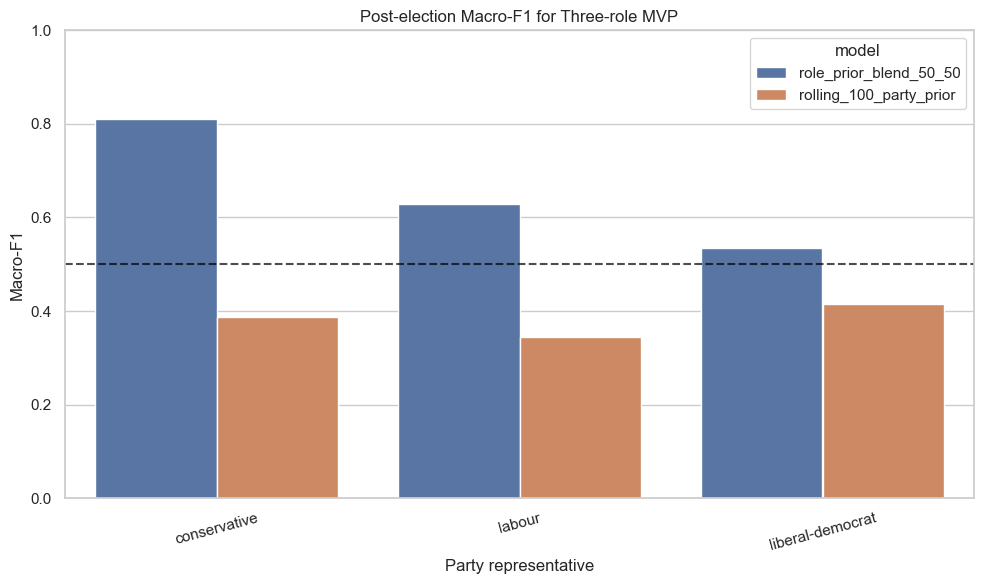

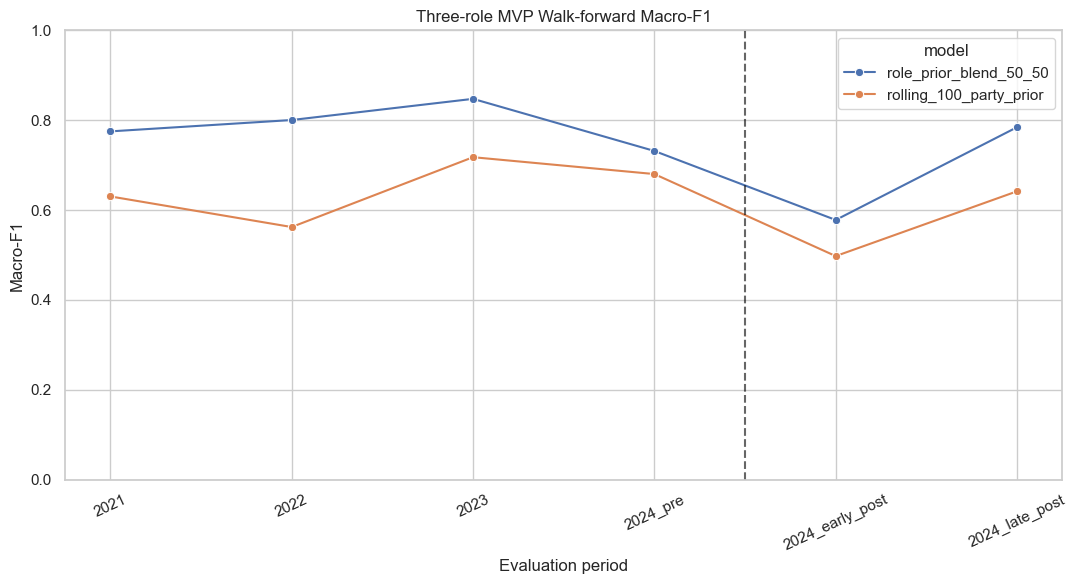

In [8]:
# 只绘制正式候选与简单基准，避免图中过多开发模型干扰产品结论
plot_models = [PRIMARY_MODEL, BASELINE_MODEL]

party_plot = post_party_metrics[
    post_party_metrics["model"].isin(plot_models)
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=party_plot,
    x="party",
    y="macro_f1",
    hue="model",
)
plt.axhline(
    MIN_POST_WORST_PARTY_MACRO_F1,
    color="black",
    linestyle="--",
    alpha=0.7,
)
plt.ylim(0, 1)
plt.title("Post-election Macro-F1 for Three-role MVP")
plt.xlabel("Party representative")
plt.ylabel("Macro-F1")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "three_role_post_party_macro_f1_v1.png", dpi=160
)
plt.show()

fold_plot = fold_metrics[
    fold_metrics["model"].isin(plot_models)
].copy()
fold_order = [
    "2021",
    "2022",
    "2023",
    "2024_pre",
    "2024_early_post",
    "2024_late_post",
]
fold_plot["fold"] = pd.Categorical(
    fold_plot["fold"], categories=fold_order, ordered=True
)

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=fold_plot.sort_values("fold"),
    x="fold",
    y="macro_f1",
    hue="model",
    marker="o",
)
plt.axvline(3.5, color="black", linestyle="--", alpha=0.6)
plt.ylim(0, 1)
plt.title("Three-role MVP Walk-forward Macro-F1")
plt.xlabel("Evaluation period")
plt.ylabel("Macro-F1")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "three_role_walk_forward_macro_f1_v1.png", dpi=160
)
plt.show()


## 8. 输出审阅摘要

请把最后的摘要完整复制回来。如果全部门槛通过，下一步只制作最终Test协议，不再修改范围、模型、融合比例或阈值。


In [9]:
primary_post_parties = (
    post_party_metrics[
        post_party_metrics["model"] == PRIMARY_MODEL
    ][["party", "rows", "macro_f1", "accuracy", "roc_auc", "brier"]]
    .sort_values("party")
)

summary_lines = [
    "=== THREE-ROLE SCOPE FREEZE SUMMARY FOR REVIEW ===",
    "Notebook version: 09c-three-role-scope-freeze-v1",
    "Model training: 0",
    "API calls: 0",
    "LLM calls: 0",
    "Test loaded: False",
    f"In-scope parties: {IN_SCOPE_PARTIES}",
    f"Out-of-scope parties: {OUT_OF_SCOPE_PARTIES}",
    f"Role mapping: {EXPECTED_POST_ELECTION_ROLES}",
    f"Role mapping effective from: {ROLE_MAPPING_EFFECTIVE_FROM}",
    f"Role mapping effective until: {ROLE_MAPPING_EFFECTIVE_UNTIL}",
    f"Candidate model: {PRIMARY_MODEL}",
    f"Baseline model: {BASELINE_MODEL}",
    f"Candidate mean-fold Macro-F1: {primary['mean_fold_macro_f1']:.3f}",
    f"Candidate worst-fold Macro-F1: {primary['worst_fold_macro_f1']:.3f}",
    f"Candidate post-election Macro-F1: "
    f"{primary['post_election_macro_f1']:.3f}",
    f"Baseline post-election Macro-F1: "
    f"{baseline['post_election_macro_f1']:.3f}",
    f"Post-election improvement: "
    f"{primary['post_election_macro_f1'] - baseline['post_election_macro_f1']:.3f}",
    f"Candidate post-election worst-party Macro-F1: "
    f"{primary['post_worst_party_macro_f1']:.3f}",
    f"Acceptance gates: {acceptance_gates}",
    f"Three-role model passes: {scope_model_passes}",
    f"Frozen model: {frozen_model}",
    f"Freeze SHA-256: {FREEZE_SHA256}",
    "Candidate post-election party metrics:",
    primary_post_parties.round(3).to_string(index=False),
    f"Next step: {next_step}",
    "RUN_FINAL_TEST: False",
    "Test result: NOT RUN",
    f"Output directory: {OUTPUT_DIR}",
    "=== END THREE-ROLE SCOPE FREEZE SUMMARY ===",
]

summary_text = "\n".join(summary_lines)
print(summary_text)
(OUTPUT_DIR / "three_role_scope_freeze_summary_v1.txt").write_text(
    summary_text, encoding="utf-8"
)


=== THREE-ROLE SCOPE FREEZE SUMMARY FOR REVIEW ===
Notebook version: 09c-three-role-scope-freeze-v1
Model training: 0
API calls: 0
LLM calls: 0
Test loaded: False
In-scope parties: ['labour', 'conservative', 'liberal-democrat']
Out-of-scope parties: ['green']
Role mapping: {'labour': 'governing_party', 'conservative': 'main_opposition', 'liberal-democrat': 'smaller_opposition'}
Role mapping effective from: 2024-07-05
Role mapping effective until: next UK general election or government change
Candidate model: role_prior_blend_50_50
Baseline model: rolling_100_party_prior
Candidate mean-fold Macro-F1: 0.753
Candidate worst-fold Macro-F1: 0.578
Candidate post-election Macro-F1: 0.719
Baseline post-election Macro-F1: 0.595
Post-election improvement: 0.124
Candidate post-election worst-party Macro-F1: 0.534
Acceptance gates: {'post_election_improvement_gate': True, 'mean_fold_gate': True, 'worst_fold_gate': True, 'post_worst_party_gate': True}
Three-role model passes: True
Frozen model: rol

1650